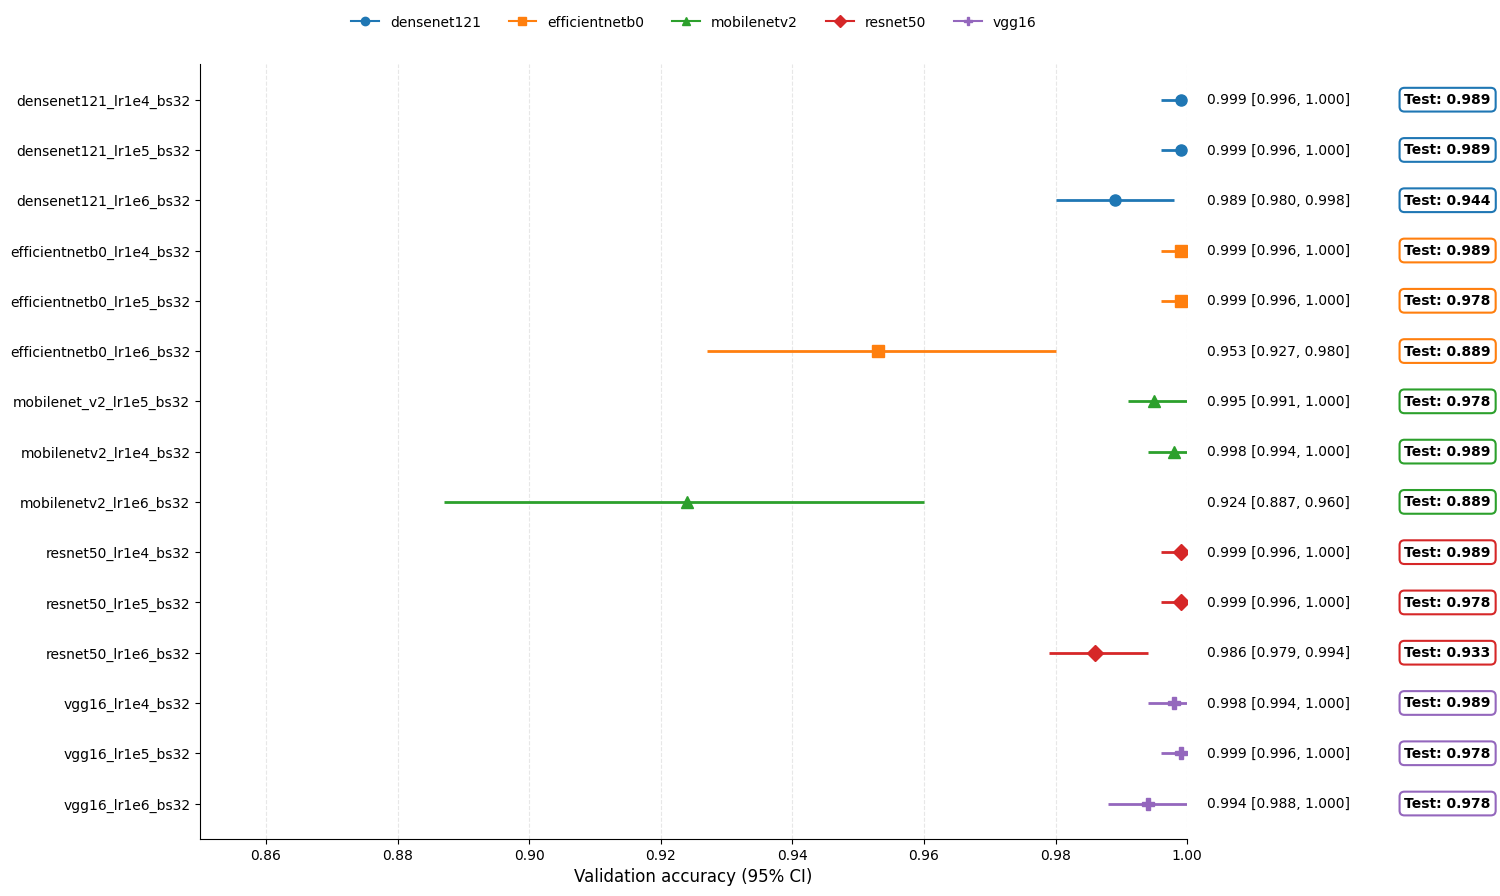

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DATOS
# =========================
rows = [
    ("densenet121_lr1e4_bs32", "densenet121", 0.999, 0.996, 1.000, 0.989),
    ("densenet121_lr1e5_bs32", "densenet121", 0.999, 0.996, 1.000, 0.989),
    ("densenet121_lr1e6_bs32", "densenet121", 0.989, 0.980, 0.998, 0.944),

    ("efficientnetb0_lr1e4_bs32", "efficientnetb0", 0.999, 0.996, 1.000, 0.989),
    ("efficientnetb0_lr1e5_bs32", "efficientnetb0", 0.999, 0.996, 1.000, 0.978),
    ("efficientnetb0_lr1e6_bs32", "efficientnetb0", 0.953, 0.927, 0.980, 0.889),

    ("mobilenet_v2_lr1e5_bs32", "mobilenetv2", 0.995, 0.991, 1.000, 0.978),
    ("mobilenetv2_lr1e4_bs32", "mobilenetv2", 0.998, 0.994, 1.000, 0.989),
    ("mobilenetv2_lr1e6_bs32", "mobilenetv2", 0.924, 0.887, 0.960, 0.889),

    ("resnet50_lr1e4_bs32", "resnet50", 0.999, 0.996, 1.000, 0.989),
    ("resnet50_lr1e5_bs32", "resnet50", 0.999, 0.996, 1.000, 0.978),
    ("resnet50_lr1e6_bs32", "resnet50", 0.986, 0.979, 0.994, 0.933),

    ("vgg16_lr1e4_bs32", "vgg16", 0.998, 0.994, 1.000, 0.989),
    ("vgg16_lr1e5_bs32", "vgg16", 0.999, 0.996, 1.000, 0.978),
    ("vgg16_lr1e6_bs32", "vgg16", 0.994, 0.988, 1.000, 0.978),
]

# =========================
# ESTILOS
# =========================
colors = {
    "densenet121": "#1f77b4",
    "efficientnetb0": "#ff7f0e",
    "mobilenetv2": "#2ca02c",
    "resnet50": "#d62728",
    "vgg16": "#9467bd",
}

markers = {
    "densenet121": "o",
    "efficientnetb0": "s",
    "mobilenetv2": "^",
    "resnet50": "D",
    "vgg16": "P",
}

# =========================
# PREPARAR DATOS
# =========================
labels = [r[0] for r in rows]
means = np.array([r[2] for r in rows])
ci_low = np.array([r[3] for r in rows])
ci_high = np.array([r[4] for r in rows])
test_scores = np.array([r[5] for r in rows])

y = np.arange(len(rows))[::-1]

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(15, 9))

for i, (label, model, mean, low, high, test) in enumerate(rows):
    yy = y[i]

    # Línea + punto (CI)
    ax.errorbar(
        mean,
        yy,
        xerr=[[mean - low], [high - mean]],
        fmt=markers[model],
        color=colors[model],
        markersize=8,
        linewidth=2,
    )

    # Texto CI (fuera del eje X)
    ax.text(
        1.02,
        yy,
        f"{mean:.3f} [{low:.3f}, {high:.3f}]",
        transform=ax.get_yaxis_transform(),
        va="center",
        fontsize=10,
    )

    # Caja Test (más a la derecha)
    ax.text(
        1.22,
        yy,
        f"Test: {test:.3f}",
        transform=ax.get_yaxis_transform(),
        va="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor=colors[model],
            linewidth=1.5,
        ),
    )

# =========================
# CONFIGURACIÓN
# =========================
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)

ax.set_xlabel("Validation accuracy (95% CI)", fontsize=12)

# Escala (puedes cambiar libremente)
ax.set_xlim(0.85, 1.00)

ax.grid(axis="x", linestyle="--", alpha=0.3)

# Leyenda
for model in colors:
    ax.plot(
        [],
        [],
        marker=markers[model],
        color=colors[model],
        label=model,
        linestyle="-",
    )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=5,
    frameon=False,
)

# Limpieza visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Espacio para textos externos
plt.subplots_adjust(right=0.75)

plt.tight_layout()
plt.savefig("1_clasificador.png", dpi=300, bbox_inches="tight")
plt.show()